In [1]:
import pandas as pd

csv_path = "extracted_err_iter.csv"

df = pd.read_csv(csv_path)
df = df.sort_values("iter").reset_index(drop=True)

burn_in = 300
window = 50
min_delta = 0.0  # 可以改成 1e-4，表示至少下降这么多才算下降

# 只看 burn-in 之后
df_check = df[df["iter"] > burn_in].copy().reset_index(drop=True)

# 计算每一行之前 50 个 test_err 的最小值
df_check["prev_50_min"] = (
    df_check["test_err"]
    .shift(1)
    .rolling(window=window, min_periods=window)
    .min()
)

# 当前 err 是否比前 50 个值的最小值下降
df_check["improved_vs_prev_50"] = (
    df_check["test_err"] < df_check["prev_50_min"] - min_delta
)

# 找出有完整前 50 个值之后，哪些没有下降
df_check["no_drop_vs_prev_50"] = (
    df_check["prev_50_min"].notna()
    & ~df_check["improved_vs_prev_50"]
)

print(df_check[["iter", "test_err", "prev_50_min", "improved_vs_prev_50", "no_drop_vs_prev_50"]])

# 如果你想找第一次“当前值没有比前50个值下降”的位置
first_no_drop = df_check[df_check["no_drop_vs_prev_50"]].head(1)

if len(first_no_drop) > 0:
    row = first_no_drop.iloc[0]
    print("\nFirst no-drop point after burn-in:")
    print(f"iter: {int(row['iter'])}")
    print(f"test_err: {row['test_err']}")
    print(f"previous 50 min: {row['prev_50_min']}")
else:
    print("\nNo no-drop point found after burn-in.")

df_check.to_csv("err_prev50_check.csv", index=False)

     iter  test_err  prev_50_min  improved_vs_prev_50  no_drop_vs_prev_50
0     301  0.904286          NaN                False               False
1     302  0.909320          NaN                False               False
2     303  0.904314          NaN                False               False
3     304  0.908546          NaN                False               False
4     305  0.913145          NaN                False               False
..    ...       ...          ...                  ...                 ...
171   472  0.920466     0.902195                False                True
172   473  0.920424     0.902195                False                True
173   474  0.926267     0.902195                False                True
174   475  0.920970     0.902195                False                True
175   476  0.925575     0.902195                False                True

[176 rows x 5 columns]

First no-drop point after burn-in:
iter: 351
test_err: 0.908108
previous 50 min: 0.8974

In [2]:
import pandas as pd

csv_path = "extracted_err_iter.csv"

df = pd.read_csv(csv_path)
df = df.sort_values("iter").reset_index(drop=True)

burn_in = 300
window = 100
min_delta = 0.0  # 可以改成 1e-4，表示至少下降这么多才算下降

# 只看 burn-in 之后
df_check = df[df["iter"] > burn_in].copy().reset_index(drop=True)

# 计算每一行之前 50 个 test_err 的最小值
df_check["prev_100_min"] = (
    df_check["test_err"]
    .shift(1)
    .rolling(window=window, min_periods=window)
    .min()
)

# 当前 err 是否比前 50 个值的最小值下降
df_check["improved_vs_prev_100"] = (
    df_check["test_err"] < df_check["prev_100_min"] - min_delta
)

# 找出有完整前 50 个值之后，哪些没有下降
df_check["no_drop_vs_prev_100"] = (
    df_check["prev_100_min"].notna()
    & ~df_check["improved_vs_prev_100"]
)

print(df_check[["iter", "test_err", "prev_100_min", "improved_vs_prev_100", "no_drop_vs_prev_100"]])

# 如果你想找第一次“当前值没有比前50个值下降”的位置
first_no_drop = df_check[df_check["no_drop_vs_prev_100"]].head(1)

if len(first_no_drop) > 0:
    row = first_no_drop.iloc[0]
    print("\nFirst no-drop point after burn-in:")
    print(f"iter: {int(row['iter'])}")
    print(f"test_err: {row['test_err']}")
    print(f"previous 100 min: {row['prev_100_min']}")
else:
    print("\nNo no-drop point found after burn-in.")

df_check.to_csv("err_prev50_check.csv", index=False)

     iter  test_err  prev_100_min  improved_vs_prev_100  no_drop_vs_prev_100
0     301  0.904286           NaN                 False                False
1     302  0.909320           NaN                 False                False
2     303  0.904314           NaN                 False                False
3     304  0.908546           NaN                 False                False
4     305  0.913145           NaN                 False                False
..    ...       ...           ...                   ...                  ...
171   472  0.920466      0.899766                 False                 True
172   473  0.920424      0.901109                 False                 True
173   474  0.926267      0.901109                 False                 True
174   475  0.920970      0.901109                 False                 True
175   476  0.925575      0.901109                 False                 True

[176 rows x 5 columns]

First no-drop point after burn-in:
iter: 401
test_e

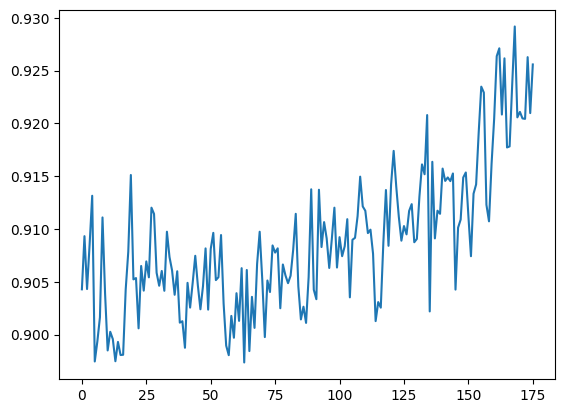

In [4]:
from matplotlib import pyplot as plt
plt.plot( df_check["test_err"])

In [5]:
import pandas as pd

csv_path = "extracted_err_iter.csv"

df = pd.read_csv(csv_path)
df = df.sort_values("iter").reset_index(drop=True)

burn_in = 300
patience = 50
min_delta = 0.0  # 可改成 1e-4

df_check = df[df["iter"] >= burn_in].copy().reset_index(drop=True)

best_err = float("inf")
best_iter = None
best_index = None
no_improve_count = 0
stop_point = None

records = []

for i, row in df_check.iterrows():
    iteration = int(row["iter"])
    err = float(row["test_err"])

    if err < best_err - min_delta:
        best_err = err
        best_iter = iteration
        best_index = i
        no_improve_count = 0
        improved = True
    else:
        no_improve_count += 1
        improved = False

    records.append({
        "iter": iteration,
        "test_err": err,
        "best_iter_so_far": best_iter,
        "best_err_so_far": best_err,
        "no_improve_count": no_improve_count,
        "improved": improved
    })

    if no_improve_count >= patience:
        stop_point = {
            "stop_iter": iteration,
            "best_iter": best_iter,
            "best_err": best_err,
            "best_index_after_burnin": best_index,
            "no_improve_count": no_improve_count
        }
        break

result = pd.DataFrame(records)

print(result)

if stop_point:
    print("\nEarly stopping triggered:")
    print(stop_point)
else:
    print("\nEarly stopping not triggered.")

result.to_csv("early_stop_after_burnin.csv", index=False)

    iter  test_err  best_iter_so_far  best_err_so_far  no_improve_count  \
0    300  0.903110               300         0.903110                 0   
1    301  0.904286               300         0.903110                 1   
2    302  0.909320               300         0.903110                 2   
3    303  0.904314               300         0.903110                 3   
4    304  0.908546               300         0.903110                 4   
5    305  0.913145               300         0.903110                 5   
6    306  0.897457               306         0.897457                 0   
7    307  0.899354               306         0.897457                 1   
8    308  0.901639               306         0.897457                 2   
9    309  0.911093               306         0.897457                 3   
10   310  0.903867               306         0.897457                 4   
11   311  0.898502               306         0.897457                 5   
12   312  0.900267       

In [3]:
import pandas as pd

csv_path = "extracted_err_iter.csv"

df = pd.read_csv(csv_path)
df = df.sort_values("iter").reset_index(drop=True)

burn_in = 300
patience = 100
min_delta = 0.0  # 可改成 1e-4

df_check = df[df["iter"] >= burn_in].copy().reset_index(drop=True)

best_err = float("inf")
best_iter = None
best_index = None
no_improve_count = 0
stop_point = None

records = []

for i, row in df_check.iterrows():
    iteration = int(row["iter"])
    err = float(row["test_err"])

    if err < best_err - min_delta:
        best_err = err
        best_iter = iteration
        best_index = i
        no_improve_count = 0
        improved = True
    else:
        no_improve_count += 1
        improved = False

    records.append({
        "iter": iteration,
        "test_err": err,
        "best_iter_so_far": best_iter,
        "best_err_so_far": best_err,
        "no_improve_count": no_improve_count,
        "improved": improved
    })

    if no_improve_count >= patience:
        stop_point = {
            "stop_iter": iteration,
            "best_iter": best_iter,
            "best_err": best_err,
            "best_index_after_burnin": best_index,
            "no_improve_count": no_improve_count
        }
        break

result = pd.DataFrame(records)

print(result)

if stop_point:
    print("\nEarly stopping triggered:")
    print(stop_point)
else:
    print("\nEarly stopping not triggered.")

result.to_csv("early_stop_after_burnin.csv", index=False)

     iter  test_err  best_iter_so_far  best_err_so_far  no_improve_count  \
0     300  0.903110               300         0.903110                 0   
1     301  0.904286               300         0.903110                 1   
2     302  0.909320               300         0.903110                 2   
3     303  0.904314               300         0.903110                 3   
4     304  0.908546               300         0.903110                 4   
..    ...       ...               ...              ...               ...   
160   460  0.916170               364         0.897362                96   
161   461  0.920426               364         0.897362                97   
162   462  0.926360               364         0.897362                98   
163   463  0.927104               364         0.897362                99   
164   464  0.920834               364         0.897362               100   

     improved  
0        True  
1       False  
2       False  
3       False  
4      

In [1]:
import pandas as pd

csv_path = "extracted_err_iter.csv"

df = pd.read_csv(csv_path)
df = df.sort_values("iter").reset_index(drop=True)

burn_in = 300
patience = 100
min_delta = 0.0  # 可改成 1e-4

df_check = df[df["iter"] >= burn_in].copy().reset_index(drop=True)

best_err = float("inf")
best_iter = None
best_index = None
no_improve_count = 0
stop_point = None

records = []

for i, row in df_check.iterrows():
    iteration = int(row["iter"])
    err = float(row["test_err"])

    if err < best_err - min_delta:
        best_err = err
        best_iter = iteration
        best_index = i
        no_improve_count = 0
        improved = True
    else:
        no_improve_count += 1
        improved = False

    records.append({
        "iter": iteration,
        "test_err": err,
        "best_iter_so_far": best_iter,
        "best_err_so_far": best_err,
        "no_improve_count": no_improve_count,
        "improved": improved
    })

    if no_improve_count >= patience:
        stop_point = {
            "stop_iter": iteration,
            "best_iter": best_iter,
            "best_err": best_err,
            "best_index_after_burnin": best_index,
            "no_improve_count": no_improve_count
        }
        break

result = pd.DataFrame(records)

print(result)

if stop_point:
    print("\nEarly stopping triggered:")
    print(stop_point)
else:
    print("\nEarly stopping not triggered.")

#result.to_csv("early_stop_after_burnin.csv", index=False)

     iter  test_err  best_iter_so_far  best_err_so_far  no_improve_count  \
0     300  0.919504               300         0.919504                 0   
1     301  0.919543               300         0.919504                 1   
2     302  0.921402               300         0.919504                 2   
3     303  0.920569               300         0.919504                 3   
4     304  0.926522               300         0.919504                 4   
..    ...       ...               ...              ...               ...   
145   445  0.939512               349         0.908562                96   
146   446  0.935449               349         0.908562                97   
147   447  0.942877               349         0.908562                98   
148   448  0.938237               349         0.908562                99   
149   449  0.934909               349         0.908562               100   

     improved  
0        True  
1       False  
2       False  
3       False  
4      

In [4]:
cc= pd.read_csv('../0617_X_matrix.csv',index_col = 0)
cc.dropna(axis = 0, how = 'all')

,Seed length,Bark thickness,Stem diameter,Seed mass,Fruit length,Dispersal length,SLA,LDMC,Leaf density,Leaf fresh mass,...,Conduit area,Lumen fraction,Fibre fraction,Root depth,Fine-root SRL,Fine-root diameter,Root density,Root N,Fine-root N,SRL
Vegetative height,,,,,,,,,,,,,,,,,,,,,
0.294125,NaN,NaN,0.538098,NaN,-0.808133,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0.699271,NaN,NaN,0.294165,2.184005,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.084744,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,-1.150848,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,-0.343665,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-2.287679,-0.450393,NaN,NaN,-0.189375,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaN,-0.782253,NaN,NaN,-0.844015,NaN,-0.785341,1.241503,-0.489699,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,-0.376985,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
